# Notebook 02 - Classical baselines (logistic regression, XGBoost)

Two arms of the comparison: independent binary classifiers fitted separately at
12, 24 and 36 months.

These are the discrimination benchmark the constrained survival models have to
beat, or fail to beat. They are also the clearest illustration of the problem
the study is about. Nothing ties the 12-month model to the 24-month model, so
nothing prevents a borrower's fitted PD(24m) from coming in below their PD(12m):
a term structure that says the borrower is less likely to have defaulted after
two years than after one. Section *PD term-structure inconsistency* counts how
often that happens.

Both arms use the shared split and feature matrix from `src/common.py` and are
scored by the shared harness in `src/evaluate.py`.

In [1]:
import sys, json
from pathlib import Path

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from sklearn.linear_model import LogisticRegression
from sklearn.metrics import roc_auc_score
from xgboost import XGBClassifier

ROOT = Path.cwd().parent if Path.cwd().name == "Notebooks" else Path.cwd()
sys.path.insert(0, str(ROOT))

from src.common import (load_data, make_split, build_features, horizon_labels,
                        describe_split, HORIZONS, SEED, RESULTS_DIR)
from src.evaluate import (evaluate_arm, horizon_models_to_survival,
                          save_arm_results, plot_calibration, comparison_table,
                          available_backends)
from src.monotonicity import audit_monotonicity, cumhaz_from_survival, format_audit

RESULTS_DIR.mkdir(exist_ok=True)
print("backends:", available_backends())

backends: {'lifelines': True, 'scikit-survival': False}


## The shared protocol

One split, one feature matrix, reused by every arm. Every transformation that
learns anything -- scaler moments, one-hot categories, the `emp_length` median
-- is fitted on train and applied to test.

In [2]:
df = load_data()
print("dataset:", df.shape)

train_df, test_df = make_split(seed=SEED)
feat = build_features(train_df, test_df)

print(describe_split(train_df, test_df).to_string(index=False))
print()
print(f"design matrix: train {feat.X_train.shape}, test {feat.X_test.shape}")
print("features:", feat.names)

dataset: (2247571, 13)


split    rows  event_rate  median_time_m
train 1573299    0.128023           18.2
 test  674272    0.127732           18.2

design matrix: train (1573299, 14), test (674272, 14)
features: ['annual_inc', 'dti', 'loan_amnt', 'int_rate', 'term', 'grade', 'emp_length_missing', 'emp_length', 'home_ownership_ANY', 'home_ownership_MORTGAGE', 'home_ownership_NONE', 'home_ownership_OTHER', 'home_ownership_OWN', 'home_ownership_RENT']


## Horizon labels

`y_H = (time <= H) & (event == 1)`. This one definition, in
`src.common.horizon_labels`, is what makes the survival arms' time-dependent
AUCs comparable to these binary AUCs.

In [3]:
y_train = horizon_labels(train_df)
y_test = horizon_labels(test_df)

print(pd.DataFrame([{"horizon": H,
                     "train_rate": y_train[H].mean(),
                     "test_rate": y_test[H].mean()} for H in HORIZONS])
      .round(6).to_string(index=False))

 horizon  train_rate  test_rate
      12    0.048539   0.048492
      24    0.099104   0.098655
      36    0.122706   0.122372


## Logistic regression

Fitted on the already-standardised shared design matrix, so there is no second
scaler and no chance of one being fitted on test rows.

In [4]:
log_models, log_auc = {}, {}
for H in HORIZONS:
    m = LogisticRegression(max_iter=1000, n_jobs=-1)
    m.fit(feat.X_train, y_train[H])
    p = m.predict_proba(feat.X_test)[:, 1]
    log_auc[H] = roc_auc_score(y_test[H], p)
    log_models[H] = m
    print(f"Logistic AUC @ {H:>2}m: {log_auc[H]:.4f}")

Logistic AUC @ 12m: 0.7012


Logistic AUC @ 24m: 0.6911


Logistic AUC @ 36m: 0.6876


## XGBoost

In [5]:
xgb_models, xgb_auc = {}, {}
for H in HORIZONS:
    m = XGBClassifier(n_estimators=200, max_depth=4, learning_rate=0.05,
                      subsample=0.8, colsample_bytree=0.8,
                      eval_metric="logloss", random_state=SEED,
                      tree_method="hist", n_jobs=-1)
    m.fit(feat.X_train, y_train[H])
    p = m.predict_proba(feat.X_test)[:, 1]
    xgb_auc[H] = roc_auc_score(y_test[H], p)
    xgb_models[H] = m
    print(f"XGBoost  AUC @ {H:>2}m: {xgb_auc[H]:.4f}")

XGBoost  AUC @ 12m: 0.7121


XGBoost  AUC @ 24m: 0.7085


XGBoost  AUC @ 36m: 0.7117


## Reconciliation with the earlier four-feature specification

Earlier versions of this project fitted these baselines on four features only
(`annual_inc`, `dti`, `loan_amnt`, `int_rate`) and reported XGBoost AUCs of
0.7068 / 0.7037 / 0.7052 and logistic AUCs of 0.6920 / 0.6800 / 0.6753.

The shared feature set is wider: it adds `term`, `grade`, `emp_length` and
`home_ownership`. `grade` in particular is Lending Club's own risk score, so it
carries a lot of signal and the headline numbers move. The cell below refits
both baselines on the old four columns so the two specifications sit side by
side and the earlier numbers can be located rather than quietly replaced.

This is a reconciliation check, not a fifth arm. Only the shared-feature models
above enter the comparison.

In [6]:
legacy = ["annual_inc", "dti", "loan_amnt", "int_rate"]
cols = [feat.names.index(c) for c in legacy]
Xtr_l, Xte_l = feat.X_train[:, cols], feat.X_test[:, cols]

rows = []
for H in HORIZONS:
    lr = LogisticRegression(max_iter=1000, n_jobs=-1).fit(Xtr_l, y_train[H])
    xg = XGBClassifier(n_estimators=200, max_depth=4, learning_rate=0.05,
                       subsample=0.8, colsample_bytree=0.8, eval_metric="logloss",
                       random_state=SEED, tree_method="hist",
                       n_jobs=-1).fit(Xtr_l, y_train[H])
    rows.append({
        "horizon": H,
        "logistic_4feat": roc_auc_score(y_test[H], lr.predict_proba(Xte_l)[:, 1]),
        "logistic_shared": log_auc[H],
        "xgboost_4feat": roc_auc_score(y_test[H], xg.predict_proba(Xte_l)[:, 1]),
        "xgboost_shared": xgb_auc[H],
    })

recon = pd.DataFrame(rows).round(4)
print(recon.to_string(index=False))
recon.to_csv(RESULTS_DIR / "nb02_feature_set_reconciliation.csv", index=False)

 horizon  logistic_4feat  logistic_shared  xgboost_4feat  xgboost_shared
      12          0.6920           0.7012         0.7068          0.7121
      24          0.6800           0.6911         0.7037          0.7085
      36          0.6753           0.6876         0.7052          0.7117


## PD term-structure inconsistency

Three independently fitted models produce three unrelated probabilities. Nothing
in the fitting procedure imposes

    PD(12m) <= PD(24m) <= PD(36m)

even though it holds by definition for any real borrower: the event *default
within 12 months* is a subset of *default within 24 months*. Below, the number
of held-out borrowers whose fitted term structure is not ordered.

In [7]:
def inversion_stats(models, name):
    p = np.column_stack([models[H].predict_proba(feat.X_test)[:, 1] for H in HORIZONS])
    inv_12_24 = (p[:, 0] > p[:, 1])
    inv_24_36 = (p[:, 1] > p[:, 2])
    any_inv = inv_12_24 | inv_24_36
    worst = float(np.max(np.maximum(p[:, 0] - p[:, 1], p[:, 1] - p[:, 2])))
    return p, {"arm": name,
               "pct_borrowers_PD12_gt_PD24": 100 * inv_12_24.mean(),
               "pct_borrowers_PD24_gt_PD36": 100 * inv_24_36.mean(),
               "pct_borrowers_any_inversion": 100 * any_inv.mean(),
               "largest_PD_reversal": worst}

p_lr, s_lr = inversion_stats(log_models, "Logistic (independent horizons)")
p_xgb, s_xgb = inversion_stats(xgb_models, "XGBoost (independent horizons)")
inv = pd.DataFrame([s_lr, s_xgb])
print(inv.round(4).to_string(index=False))
inv.to_csv(RESULTS_DIR / "nb02_pd_inversions.csv", index=False)

                            arm  pct_borrowers_PD12_gt_PD24  pct_borrowers_PD24_gt_PD36  pct_borrowers_any_inversion  largest_PD_reversal
Logistic (independent horizons)                      0.0119                      0.0458                       0.0461               0.0220
 XGBoost (independent horizons)                      0.1062                      1.6170                       1.6874               0.1511


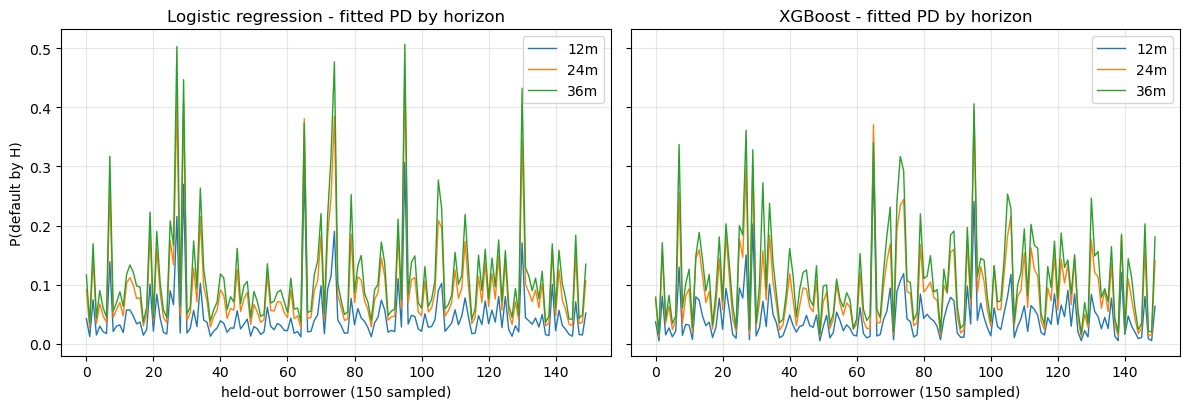

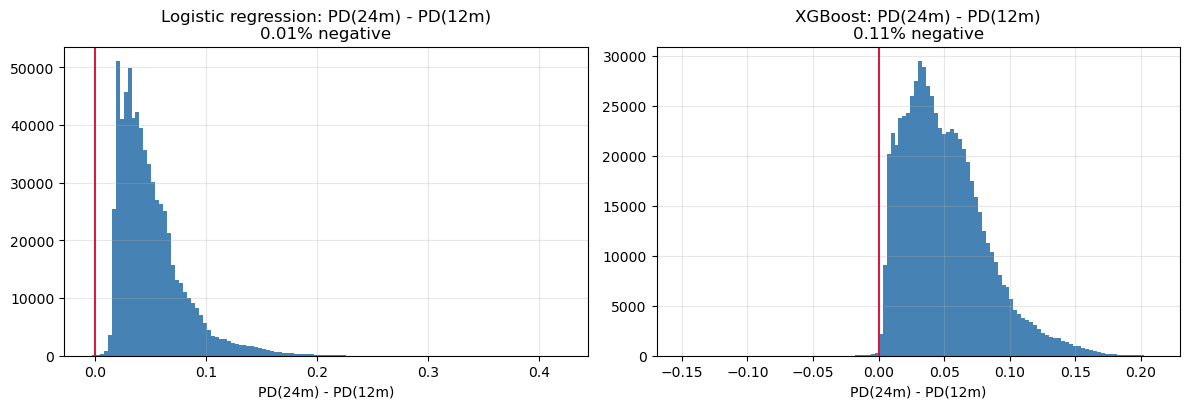

In [8]:
fig, axes = plt.subplots(1, 2, figsize=(12, 4.2), sharey=True)
rng = np.random.default_rng(SEED)
show = rng.choice(len(feat.X_test), 150, replace=False)

for ax, p, ttl in ((axes[0], p_lr, "Logistic regression"),
                   (axes[1], p_xgb, "XGBoost")):
    for k, H in enumerate(HORIZONS):
        ax.plot(p[show, k], lw=1, label=f"{H}m")
    ax.set_title(f"{ttl} - fitted PD by horizon")
    ax.set_xlabel("held-out borrower (150 sampled)")
    ax.legend(); ax.grid(alpha=0.3)
axes[0].set_ylabel("P(default by H)")
plt.tight_layout(); plt.show()

fig, axes = plt.subplots(1, 2, figsize=(12, 4.2))
for ax, p, ttl in ((axes[0], p_lr, "Logistic regression"),
                   (axes[1], p_xgb, "XGBoost")):
    d = p[:, 1] - p[:, 0]
    ax.hist(d, bins=120, color="steelblue")
    ax.axvline(0, color="crimson", lw=1.4)
    ax.set_title(f"{ttl}: PD(24m) - PD(12m)\n{100 * (d < 0).mean():.2f}% negative")
    ax.set_xlabel("PD(24m) - PD(12m)"); ax.grid(alpha=0.3)
plt.tight_layout(); plt.show()

## Scoring through the shared harness

To place these arms on the same axes as the survival models, the three
independent classifiers are wrapped as a survival function: `S(H) = 1 - PD(H)`
at the fitted horizons, linearly interpolated in between, anchored at `S(0) = 1`.

No sorting, clipping or monotone envelope is applied on the way through. If the
fitted PDs are out of order, the resulting `S(t)` goes up, and the monotonicity
audit reports it. Repairing it here would hide the exact quantity the study
exists to measure.

Past 36 months the curve is held flat. These models say nothing about month 37
onwards, and every way of inventing a continuation is arbitrary; holding the last
value constant is the choice that adds the least. Extrapolating the 24-to-36
month slope would push predicted survival far below anything the model claims and
would fill 40% of the 1-60 month Brier integral with an artefact of the wrapper.
The right way to read the integrated Brier score for these two arms is therefore
"undefined past 36 months, held flat", not as a genuine 60-month forecast.

Because the curve is piecewise linear through only three anchors, the audit's
point-level percentage for these arms reflects the interpolation as much as the
model, and the flat tail contributes no violations either way. The
borrower-level percentage is the number to read.

In [9]:
proba = lambda m, X: m.predict_proba(X)[:, 1]

results, monos = [], []
for models, name in ((log_models, "Logistic (independent horizons)"),
                     (xgb_models, "XGBoost (independent horizons)")):
    surv = horizon_models_to_survival(models, HORIZONS, proba)
    res = evaluate_arm(surv, feat.X_test, test_df, train_df, name=name)
    mono = audit_monotonicity(cumhaz_from_survival(surv), feat.X_test, name=name)
    save_arm_results(res, mono)
    results.append(res); monos.append(mono)
    print(res); print()

print(comparison_table(results).round(4).to_string(index=False))

EvalResult(Logistic (independent horizons))
                            arm  auc_12m  auc_24m  auc_36m  c_harrell   c_uno  ibs_1_60m
Logistic (independent horizons) 0.701238 0.691099 0.687588   0.680364 0.64193   0.150114



EvalResult(XGBoost (independent horizons))
                           arm  auc_12m  auc_24m  auc_36m  c_harrell   c_uno  ibs_1_60m
XGBoost (independent horizons) 0.712118 0.708462 0.711715   0.686474 0.65225   0.147812

                            arm  auc_12m  auc_24m  auc_36m  c_harrell  c_uno  ibs_1_60m
Logistic (independent horizons)   0.7012   0.6911   0.6876     0.6804 0.6419     0.1501
 XGBoost (independent horizons)   0.7121   0.7085   0.7117     0.6865 0.6523     0.1478


In [10]:
print("Monotonicity audit")
print(format_audit(pd.DataFrame(monos)).to_string(index=False))

Monotonicity audit
                            arm  n_borrowers  n_grid_points  pct_points_violating  pct_borrowers_violating  max_violation_dLam_dt  max_violation_dLam  max_survival_increase
Logistic (independent horizons)         1000            119                 0.000                      0.0               0.000000            0.000000               0.000000
 XGBoost (independent horizons)         1000            119                 0.183                      0.9               0.001098            0.000549               0.000427


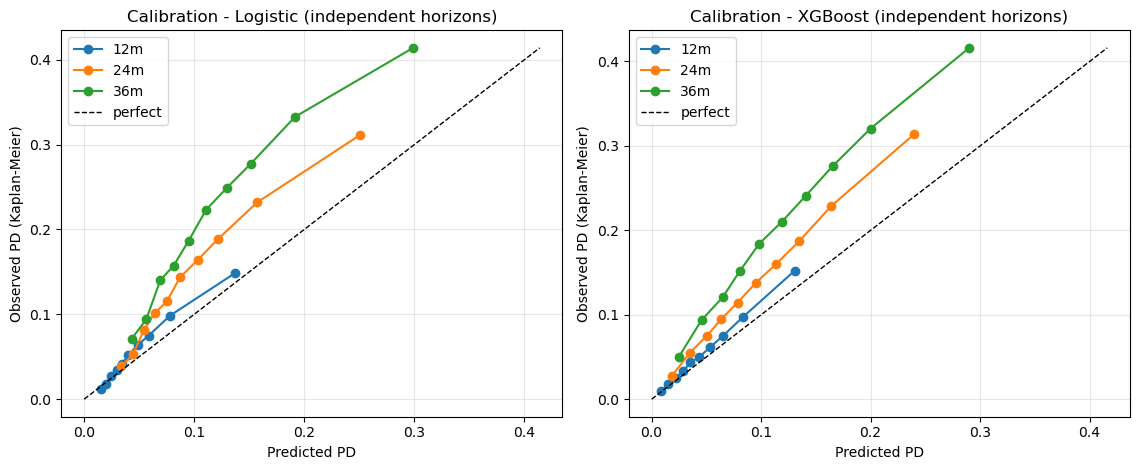

In [11]:
fig, axes = plt.subplots(1, 2, figsize=(11.5, 4.8))
for ax, r in zip(axes, results):
    plot_calibration(r, ax=ax)
plt.tight_layout(); plt.show()

## Summary

Both arms discriminate acceptably and neither produces a valid term structure.
The AUCs above are the bar the constrained survival models are measured against;
the inversion counts are the cost of not imposing structure.

The results are written to `results/` and pulled back together, alongside the
neural arms, in notebook 04.